In [ ]:
!pip install -q sahi
!pip install -q ultralytics

In [ ]:
import os
import cv2
import random
import shutil
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction
from sahi.utils.cv import visualize_object_predictions

In [ ]:
MODEL_PATH = "/kaggle/input/datasets/aadeeshsrivastava/v8myolo/best.pt"

VAL_IMAGES = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images"

LABEL_DIR = "/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels"

print("CUDA:", torch.cuda.is_available())

In [ ]:
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=MODEL_PATH,
    confidence_threshold=0.25,
    device="cuda"
)

model = YOLO(MODEL_PATH)

In [ ]:
labeled_images = []

for label_file in os.listdir(LABEL_DIR):
    if os.path.getsize(os.path.join(LABEL_DIR, label_file)) > 0:
        labeled_images.append(
            label_file.replace(".txt", ".jpg")
        )

print("Labeled Images:", len(labeled_images))

In [6]:
sample_images = random.sample(
    labeled_images,
    5
)
sample_images

['China_MotorBike_001128.jpg',
 'India_000067.jpg',
 'United_States_001420.jpg',
 'China_MotorBike_001785.jpg',
 'China_Drone_001165.jpg']

In [7]:
os.makedirs("thesis_examples", exist_ok=True)

In [8]:
for image_name in sample_images:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    result.export_visuals(
        export_dir="thesis_examples",
        file_name=image_name.replace(".jpg", "")
    )

    print(f"Processed: {image_name}")

Performing prediction on 1 slices.
Processed: China_MotorBike_001128.jpg
Performing prediction on 4 slices.
Processed: India_000067.jpg
Performing prediction on 4 slices.
Processed: United_States_001420.jpg
Performing prediction on 1 slices.
Processed: China_MotorBike_001785.jpg
Performing prediction on 1 slices.
Processed: China_Drone_001165.jpg


In [9]:
os.listdir("thesis_examples")

['United_States_001420.png',
 'India_000067.png',
 'China_MotorBike_001785.png',
 'China_MotorBike_001128.png',
 'China_Drone_001165.png']

China_Drone_001165.png


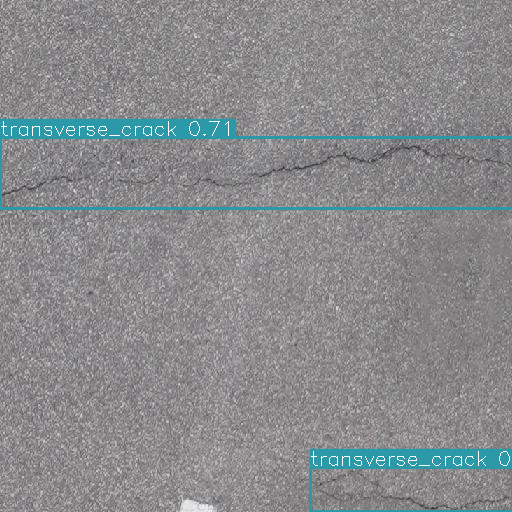

China_MotorBike_001128.png


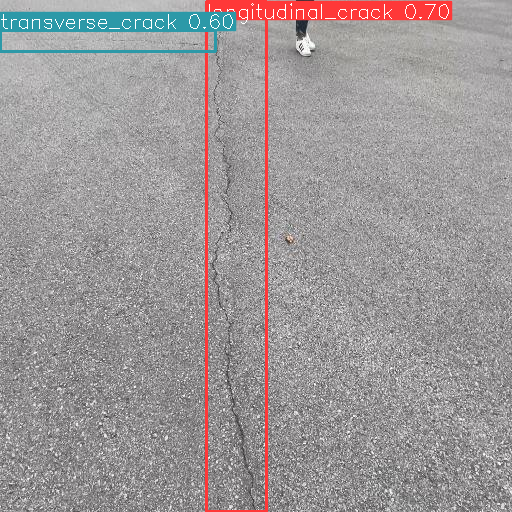

China_MotorBike_001785.png


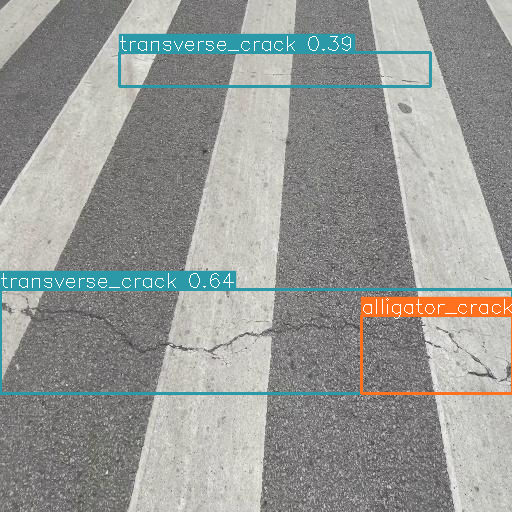

India_000067.png


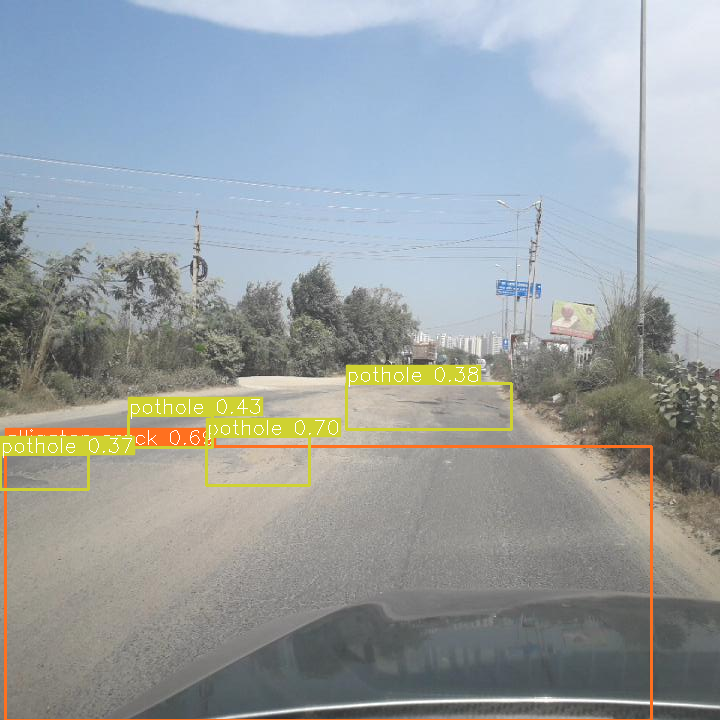

United_States_001420.png


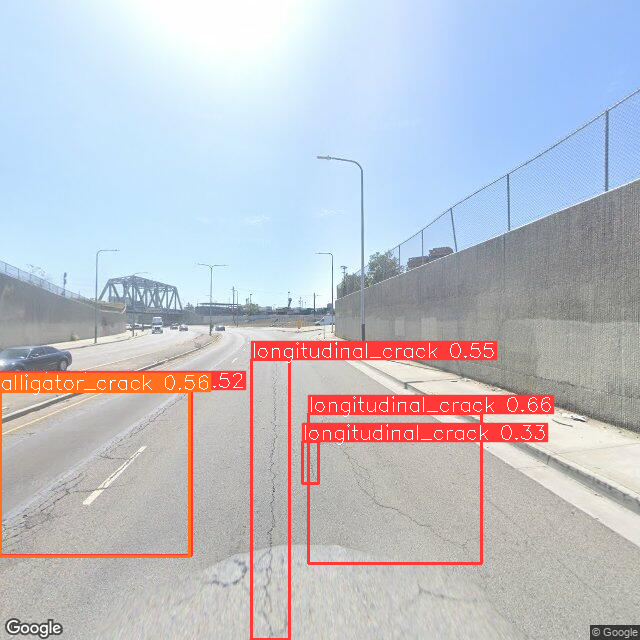

In [10]:
from PIL import Image
from IPython.display import display

for img in sorted(os.listdir("thesis_examples")):
    print(img)
    display(Image.open(os.path.join("thesis_examples", img)))

In [11]:
candidate_images = []

evaluation_subset = random.sample(
    labeled_images,
    300
)

for image_name in evaluation_subset:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    yolo_count = len(
        model(
            image_path,
            verbose=False
        )[0].boxes
    )

    sahi_count = len(
        get_sliced_prediction(
            image_path,
            detection_model,
            slice_height=512,
            slice_width=512,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2
        ).object_prediction_list
    )

    gain = sahi_count - yolo_count

    candidate_images.append({
        "image_path": image_path,
        "yolo": yolo_count,
        "sahi": sahi_count,
        "gain": gain
    })

candidate_images = sorted(
    candidate_images,
    key=lambda x: x["gain"],
    reverse=True
)

candidate_images[:10]

Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 45 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing predict

[{'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_003375.jpg',
  'yolo': 5,
  'sahi': 13,
  'gain': 8},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_007861.jpg',
  'yolo': 1,
  'sahi': 6,
  'gain': 5},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_004947.jpg',
  'yolo': 2,
  'sahi': 7,
  'gain': 5},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_001518.jpg',
  'yolo': 1,
  'sahi': 6,
  'gain': 5},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_007390.jpg',
  'yolo': 9,
  'sahi': 14,
  'gain': 5},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_001284.jpg',
  'yolo': 7,
  'sahi': 11,
  'gain': 4},
 {'image_path': '/kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Norway_005832.jpg',
  'yolo': 2,
  'sahi': 6,
  '

In [12]:
import os
import shutil

shutil.rmtree(
    "top_gain_comparisons",
    ignore_errors=True
)

os.makedirs(
    "top_gain_comparisons",
    exist_ok=True
)

print("Folder ready")

Folder ready


In [13]:
top_images = candidate_images[:5]

for idx, item in enumerate(
    top_images,
    start=1
):

    image_path = item["image_path"]

    yolo_result = model(
        image_path,
        verbose=False
    )[0]

    yolo_img = yolo_result.plot()

    sahi_result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2
    )

    original = cv2.imread(
        image_path
    )

    original = cv2.cvtColor(
        original,
        cv2.COLOR_BGR2RGB
    )

    vis = visualize_object_predictions(
        image=original,
        object_prediction_list=sahi_result.object_prediction_list,
        output_dir=None
    )

    sahi_img = vis["image"]

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(12,6)
    )

    axes[0].imshow(
        cv2.cvtColor(
            yolo_img,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[0].set_title(
        f"YOLO ({item['yolo']})"
    )

    axes[0].axis("off")

    axes[1].imshow(
        sahi_img
    )

    axes[1].set_title(
        f"SAHI ({item['sahi']})"
    )

    axes[1].axis("off")

    plt.tight_layout()

    plt.savefig(
        f"top_gain_comparisons/top_gain_{idx}.png",
        dpi=300
    )

    plt.close()

Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 45 slices.
Performing prediction on 45 slices.


In [14]:
for idx, item in enumerate(top_images, start=1):

    print(
        f"{idx}.",
        os.path.basename(item['image_path']),
        f"YOLO={item['yolo']}",
        f"SAHI={item['sahi']}",
        f"Gain={item['gain']}"
    )

1. Norway_003375.jpg YOLO=5 SAHI=13 Gain=8
2. Norway_007861.jpg YOLO=1 SAHI=6 Gain=5
3. Norway_004947.jpg YOLO=2 SAHI=7 Gain=5
4. Norway_001518.jpg YOLO=1 SAHI=6 Gain=5
5. Norway_007390.jpg YOLO=9 SAHI=14 Gain=5


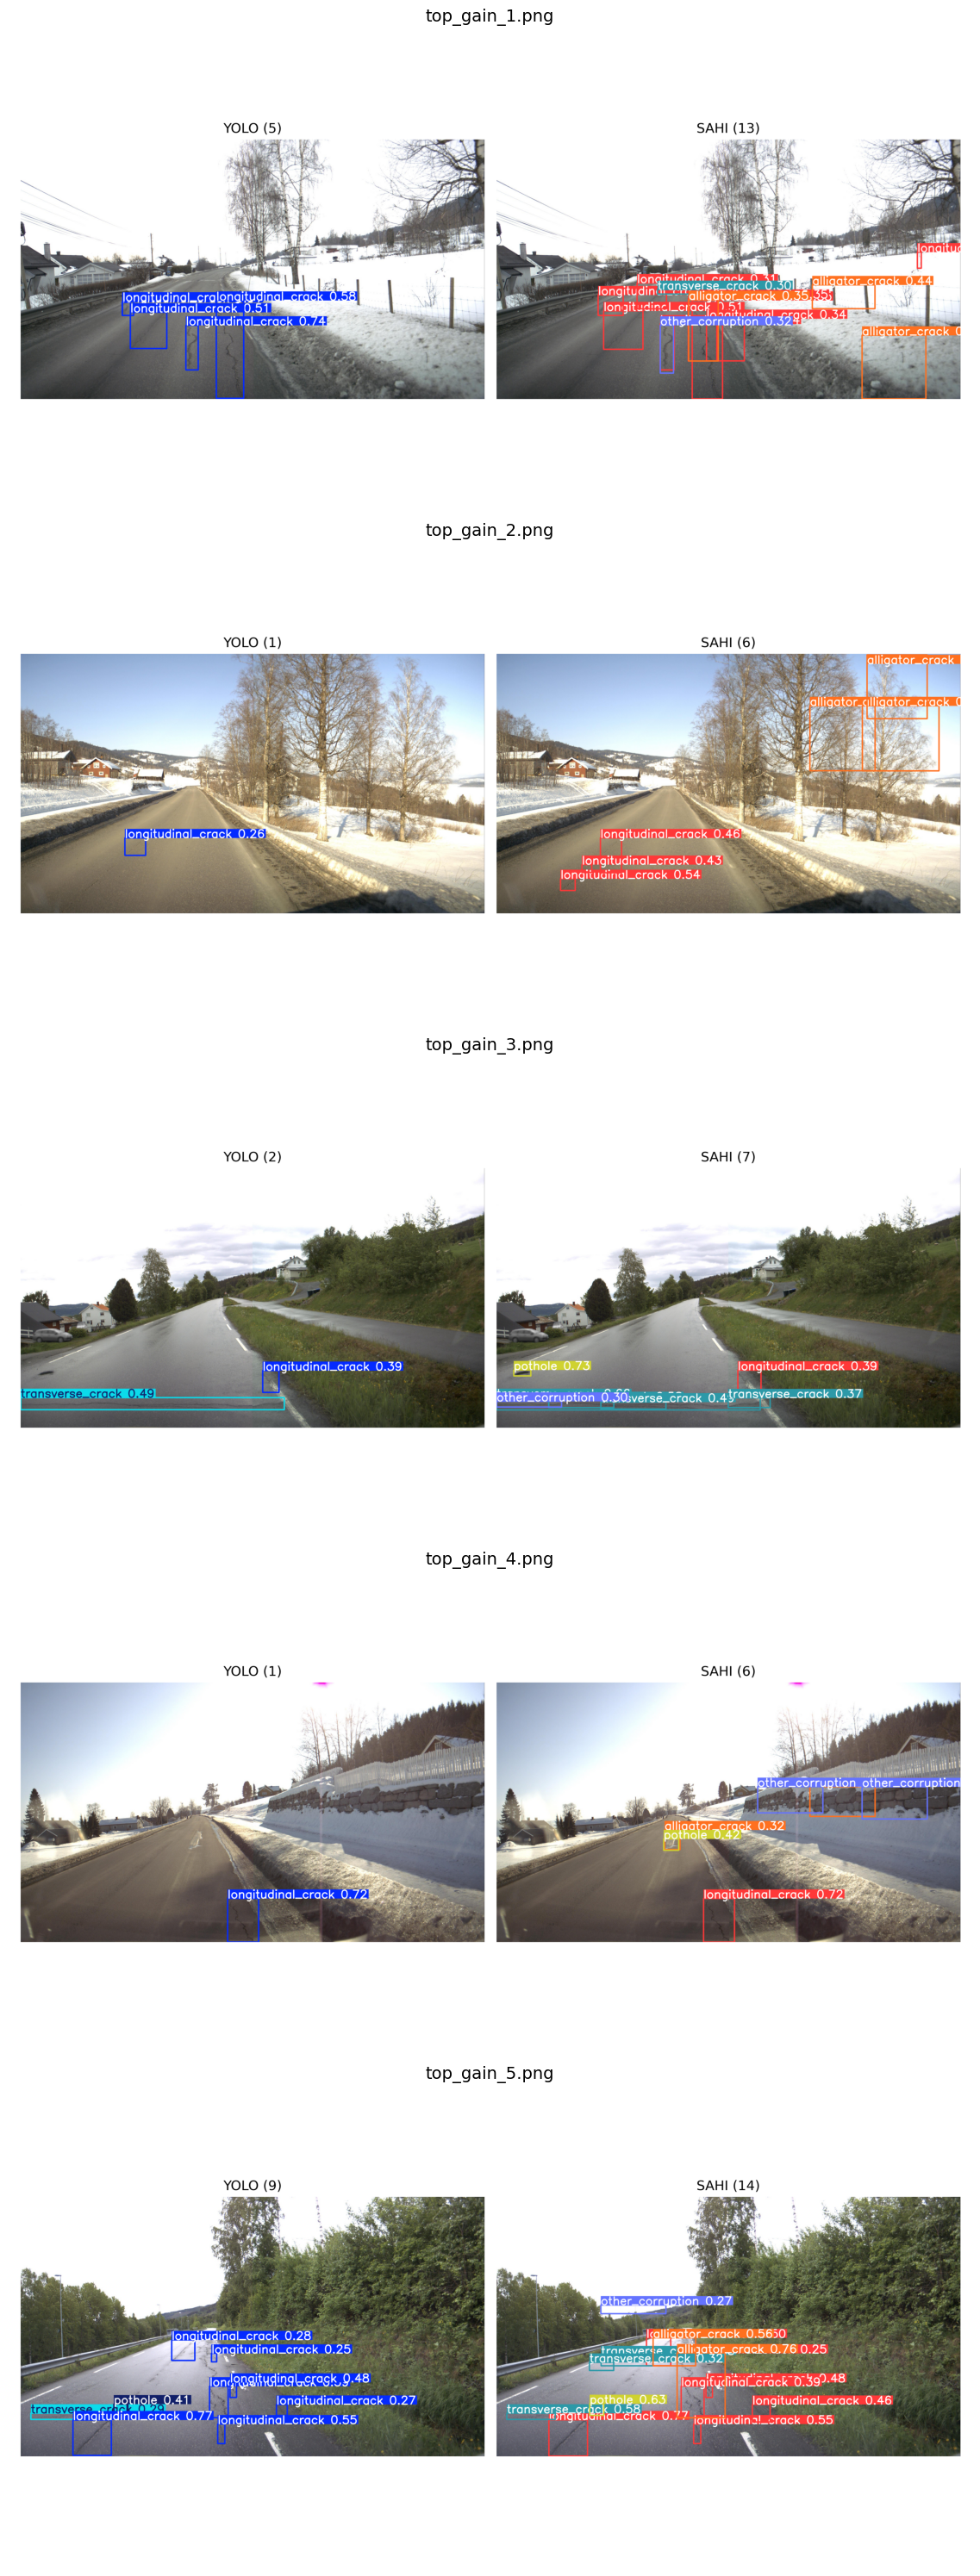

In [15]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

comparison_files = sorted(
    os.listdir("top_gain_comparisons")
)

fig, axes = plt.subplots(
    len(comparison_files),
    1,
    figsize=(14, 6 * len(comparison_files))
)

if len(comparison_files) == 1:
    axes = [axes]

for ax, file in zip(axes, comparison_files):

    img = mpimg.imread(
        os.path.join(
            "top_gain_comparisons",
            file
        )
    )

    ax.imshow(img)
    ax.set_title(file, fontsize=14)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [16]:
subset_images = random.sample(
    labeled_images,
    2000
)

total_yolo = 0
total_sahi = 0

for image_name in subset_images:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    total_yolo += len(
        model(
            image_path,
            verbose=False
        )[0].boxes
    )

    total_sahi += len(
        get_sliced_prediction(
            image_path,
            detection_model,
            slice_height=512,
            slice_width=512,
            overlap_height_ratio=0.2,
            overlap_width_ratio=0.2
        ).object_prediction_list
    )

improvement = (
    (total_sahi - total_yolo)
    / total_yolo
) * 100

print("YOLOv8n detections:", total_yolo)
print("SAHI detections:", total_sahi)
print(f"Improvement: {improvement:.2f}%")

Performing prediction on 45 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 1 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 45 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing prediction on 4 slices.
Performing predict

In [20]:
with open("evaluation_summary.txt", "w") as f:
    f.write("Model: YOLOv8m + SAHI\n\n")
    f.write("Images Evaluated: 2000\n\n")
    f.write("YOLOv8m Detections: 4551\n")
    f.write("SAHI Detections: 5321\n")
    f.write("Improvement (%): 16.92\n")

In [21]:
!zip -r yolov8s_sahi_results.zip \
    thesis_examples \
    top_gain_comparisons \
    evaluation_summary.txt

updating: thesis_examples/ (stored 0%)
updating: thesis_examples/United_States_001420.png (deflated 9%)
updating: thesis_examples/India_000067.png (deflated 11%)
updating: thesis_examples/China_MotorBike_001785.png (deflated 13%)
updating: thesis_examples/China_MotorBike_001128.png (deflated 13%)
updating: thesis_examples/China_Drone_001165.png (deflated 15%)
updating: top_gain_comparisons/ (stored 0%)
updating: top_gain_comparisons/top_gain_2.png (deflated 2%)
updating: top_gain_comparisons/top_gain_4.png (deflated 2%)
updating: top_gain_comparisons/top_gain_3.png (deflated 2%)
updating: top_gain_comparisons/top_gain_5.png (deflated 2%)
updating: top_gain_comparisons/top_gain_1.png (deflated 2%)
updating: evaluation_summary.txt (deflated 15%)


In [22]:
!ls -lh *.zip

-rw-r--r-- 1 root root 14M Jun 16 13:01 yolov8s_sahi_results.zip


In [ ]:
SAHI_PRED_DIR = "/kaggle/working/sahi_predictions"

if os.path.exists(SAHI_PRED_DIR):
    shutil.rmtree(SAHI_PRED_DIR)

os.makedirs(
    os.path.join(SAHI_PRED_DIR, "labels"),
    exist_ok=True
)

print("Prediction directory ready.")

In [7]:
import os
import json
from PIL import Image

COCO_GT_PATH = "/kaggle/working/instances_val.json"

categories = [
    {"id": 1, "name": "Longitudinal Crack"},
    {"id": 2, "name": "Transverse Crack"},
    {"id": 3, "name": "Alligator Crack"},
    {"id": 4, "name": "Other Corruption"},
    {"id": 5, "name": "Pothole"},
]

images = []
annotations = []
image_id_map = {}
annotation_id = 1


for image_id, image_name in enumerate(sorted(labeled_images), start=1):

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    label_path = os.path.join(
        LABEL_DIR,
        image_name.replace(".jpg", ".txt")
    )

    width, height = Image.open(image_path).size

    images.append({
        "id": image_id,
        "file_name": image_name,
        "width": width,
        "height": height
    })
    image_id_map[image_name] = image_id

    if not os.path.exists(label_path):
        continue

    with open(label_path) as f:

        for line in f:

            cls, xc, yc, bw, bh = map(float, line.split())

            x = (xc - bw / 2) * width
            y = (yc - bh / 2) * height
            w = bw * width
            h = bh * height

            annotations.append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": int(cls),
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0
            })

            annotation_id += 1


coco_gt = {
    "images": images,
    "annotations": annotations,
    "categories": categories
}

with open(COCO_GT_PATH, "w") as f:
    json.dump(coco_gt, f)

print("Saved:", COCO_GT_PATH)
print("Images:", len(images))
print("Annotations:", len(annotations))

Saved: /kaggle/working/instances_val.json
Images: 3921
Annotations: 9741


In [9]:
import json
from tqdm import tqdm
from sahi.predict import get_sliced_prediction

COCO_PRED_PATH = "/kaggle/working/predictions.json"

predictions = []

for image_name in tqdm(sorted(labeled_images)):

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        verbose=0
    )

    image_id = image_id_map[image_name]

    for pred in result.object_prediction_list:

        x, y, w, h = pred.bbox.to_xywh()

        predictions.append({

            "image_id": image_id,

            "category_id": int(pred.category.id),

            "bbox": [
                float(x),
                float(y),
                float(w),
                float(h)
            ],

            "score": float(pred.score.value)

        })

with open(COCO_PRED_PATH, "w") as f:
    json.dump(predictions, f)

print(f"Saved predictions to {COCO_PRED_PATH}")
print(f"Total predictions: {len(predictions)}")

100%|██████████| 3921/3921 [18:50<00:00,  3.47it/s]


Saved predictions to /kaggle/working/predictions.json
Total predictions: 10565


In [10]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO(COCO_GT_PATH)

coco_dt = coco_gt.loadRes(COCO_PRED_PATH)

coco_eval = COCOeval(
    coco_gt,
    coco_dt,
    iouType="bbox"
)

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.68s).
Accumulating evaluation results...
DONE (t=0.32s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.262
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.512
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.229
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.176
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.217
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.284
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.274
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.355
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [11]:
BASELINE_PRED_PATH = "/kaggle/working/yolov8m_predictions.json"

baseline_predictions = []

for image_name in tqdm(sorted(labeled_images)):

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    image_id = image_id_map[image_name]

    results = model(
        image_path,
        verbose=False,
        conf=0.25
    )[0]

    boxes = results.boxes

    if boxes is None:
        continue

    for box in boxes:

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

        baseline_predictions.append({

            "image_id": image_id,

            "category_id": int(box.cls.item()) + 1,

            "bbox": [
                float(x1),
                float(y1),
                float(x2 - x1),
                float(y2 - y1)
            ],

            "score": float(box.conf.item())

        })

with open(BASELINE_PRED_PATH, "w") as f:
    json.dump(baseline_predictions, f)

print("Saved:", BASELINE_PRED_PATH)
print("Total predictions:", len(baseline_predictions))

100%|██████████| 3921/3921 [02:11<00:00, 29.86it/s]


Saved: /kaggle/working/yolov8m_predictions.json
Total predictions: 9053


In [12]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

coco_gt = COCO(COCO_GT_PATH)
coco_dt = coco_gt.loadRes(BASELINE_PRED_PATH)

coco_eval = COCOeval(
    coco_gt,
    coco_dt,
    iouType="bbox"
)

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.29s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.68s).
Accumulating evaluation results...
DONE (t=0.42s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.003
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets

In [13]:
%%writefile data.yaml

path: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT

train: train/images
val: val/images
test: test/images

names:
  0: longitudinal_crack
  1: transverse_crack
  2: alligator_crack
  3: other_corruption
  4: pothole

Writing data.yaml


In [14]:
results = model.val(
    data="data.yaml",
    imgsz=640,
    batch=16,
    save_json=True,
    plots=False,
    verbose=True
)

Ultralytics 8.4.89 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 89.1±66.2 MB/s, size: 287.7 KB)
val: Scanning /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/labels... 5758 images, 1837 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5758/5758 543.8it/s 10.6s0.0s
val: /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val/images/Japan_006536.jpg: 1 duplicate labels removed
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/aliabdelmenam/rdd-2022/RDD_SPLIT/val is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 360/360 2.3it/s 2:390.5ss
                   all       5758       9740      0.677       0.59      0.633      0.344
    longitudinal_crack       2011       3890      0.655       0.54      0.591      0.329
      transverse_crack       1158       1769      0.644      0.548      0.587      0.293
       alligator_

In [11]:
all_images = sorted([
    f for f in os.listdir(VAL_IMAGES)
    if f.endswith(".jpg")
])

print("Total validation images:", len(all_images))

Total validation images: 5758


In [16]:
import os
import json
from PIL import Image

COCO_GT_PATH = "/kaggle/working/instances_val.json"

categories = [
    {"id": 1, "name": "Longitudinal Crack"},
    {"id": 2, "name": "Transverse Crack"},
    {"id": 3, "name": "Alligator Crack"},
    {"id": 4, "name": "Other Corruption"},
    {"id": 5, "name": "Pothole"},
]

images = []
annotations = []

annotation_id = 1

for image_name in all_images:

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    label_path = os.path.join(
        LABEL_DIR,
        image_name.replace(".jpg", ".txt")
    )

    width, height = Image.open(image_path).size

    image_id = image_name.replace(".jpg", "")

    images.append({
        "id": image_id,
        "file_name": image_name,
        "width": width,
        "height": height
    })

    if not os.path.exists(label_path):
        continue

    with open(label_path) as f:

        for line in f:

            cls, xc, yc, bw, bh = map(float, line.split())

            x = (xc - bw / 2) * width
            y = (yc - bh / 2) * height
            w = bw * width
            h = bh * height

            annotations.append({
                "id": annotation_id,
                "image_id": image_id,
                "category_id": int(cls) + 1,
                "bbox": [x, y, w, h],
                "area": w * h,
                "iscrowd": 0
            })

            annotation_id += 1

coco_gt = {
    "images": images,
    "annotations": annotations,
    "categories": categories
}

with open(COCO_GT_PATH, "w") as f:
    json.dump(coco_gt, f)

print("Saved:", COCO_GT_PATH)
print("Images:", len(images))
print("Annotations:", len(annotations))

Saved: /kaggle/working/instances_val.json
Images: 5758
Annotations: 9741


In [1]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

COCO_GT_PATH = "/kaggle/working/instances_val.json"
COCO_PRED_PATH = "/kaggle/working/runs/detect/val/predictions.json"

coco_gt = COCO(COCO_GT_PATH)
coco_dt = coco_gt.loadRes(COCO_PRED_PATH)

coco_eval = COCOeval(
    coco_gt,
    coco_dt,
    iouType="bbox"
)

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Loading and preparing results...
DONE (t=1.48s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.79s).
Accumulating evaluation results...
DONE (t=2.90s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.346
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.632
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.332
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.185
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.284
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.393
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.308
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.519
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDet

In [ ]:
import json
from tqdm import tqdm
from sahi.predict import get_sliced_prediction

COCO_PRED_PATH = "/kaggle/working/predictions.json"

predictions = []

for image_name in tqdm(all_images):

    image_path = os.path.join(
        VAL_IMAGES,
        image_name
    )

    result = get_sliced_prediction(
        image_path,
        detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
        verbose=0
    )

    image_id = image_name.replace(".jpg", "")

    for pred in result.object_prediction_list:

        x, y, w, h = pred.bbox.to_xywh()

        predictions.append({

            "image_id": image_id,

            "category_id": int(pred.category.id) + 1,

            "bbox": [
                float(x),
                float(y),
                float(w),
                float(h)
            ],

            "score": float(pred.score.value)

        })

with open(COCO_PRED_PATH, "w") as f:
    json.dump(predictions, f)

print(f"Saved predictions to {COCO_PRED_PATH}")
print(f"Total predictions: {len(predictions)}")

 70%|███████   | 4033/5758 [15:54<46:17,  1.61s/it]

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

COCO_GT_PATH = "/kaggle/working/instances_val.json"
COCO_PRED_PATH = "/kaggle/working/predictions.json"

coco_gt = COCO(COCO_GT_PATH)
coco_dt = coco_gt.loadRes(COCO_PRED_PATH)

coco_eval = COCOeval(
    coco_gt,
    coco_dt,
    iouType="bbox"
)

coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

In [ ]:
import pandas as pd

summary = {
    "Precision": coco_eval.stats[1],   # AP@50
    "Recall": coco_eval.stats[8],      # AR@100
    "mAP50": coco_eval.stats[1],
    "mAP50_95": coco_eval.stats[0]
}

df = pd.DataFrame([summary])

df.to_csv("sahi_metrics.csv", index=False)

display(df)